In [156]:

# IMPORTS

# pip install scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import metrics

# pip install tensorflow
import tensorflow as tf
import keras
from keras import layers




In [157]:
df = pd.read_csv('lego_sets.csv')

df.dtypes

ages                     str
list_price           float64
num_reviews          float64
piece_count          float64
play_star_rating     float64
prod_desc                str
prod_id              float64
prod_long_desc           str
review_difficulty        str
set_name                 str
star_rating          float64
theme_name               str
val_star_rating      float64
country                  str
dtype: object

In [158]:
df['ages'].value_counts()
# Separate this column to only show minAge

ages
6-12     1476
7-14     1421
8-14     1180
4-7       957
5-12      911
10+       870
2-5       840
7-12      723
9-14      624
16+       420
8-12      350
4-99      311
12+       298
6-14      233
8+        226
1½-3      213
14+       212
10-21     184
6+        148
10-16     148
1½-5      113
9-16       92
5+         71
11-16      66
9-12       46
12-16      42
4+         21
9+         21
5-8        21
10-14      21
7+          2
Name: count, dtype: int64

In [159]:
# This code is 98% claude
# The primary function is to separate the 'ages' column into two different columns - min and max ages

import re

def parse_min_age(age_str):
    if pd.isna(age_str):
        return None

    age_str = str(age_str).strip()
    age_str = age_str.replace('½', '.5')  # handle fractions like 1½ -> 1.5

    # Grab the first number in the string. This covers "12+", "12-16", and "2".
    match = re.search(r'\d*\.?\d+', age_str)
    return float(match.group()) if match else None

df['min_age'] = df['ages'].apply(parse_min_age)



In [160]:
df['country'].unique()

<StringArray>
['US', 'AU', 'AT', 'BE', 'CA', 'CH', 'CZ', 'DE', 'DN', 'ES', 'FI', 'FR', 'GB',
 'IE', 'IT', 'LU', 'NO', 'NL', 'NZ', 'PL', 'PT']
Length: 21, dtype: str

In [161]:
country_to_continent = {
    'US': 'North America',
    'CA': 'North America',
    'AU': 'Oceania',
    'NZ': 'Oceania',
    'AT': 'Europe',
    'BE': 'Europe',
    'CH': 'Europe',
    'CZ': 'Europe',
    'DE': 'Europe',
    'DN': 'Europe',   
    'ES': 'Europe',
    'FI': 'Europe',
    'FR': 'Europe',
    'GB': 'Europe',
    'IE': 'Europe',
    'IT': 'Europe',
    'LU': 'Europe',
    'NO': 'Europe',
    'NL': 'Europe',
    'PL': 'Europe',
    'PT': 'Europe',
}

df['continent'] = df['country'].map(country_to_continent)
df = df.drop('country', axis=1)

In [162]:
# Separate the 'continent' column to it's own columns

df = pd.get_dummies(df, columns=['continent'], dtype=int)
df.head()

,ages,list_price,num_reviews,piece_count,play_star_rating,prod_desc,prod_id,prod_long_desc,review_difficulty,set_name,star_rating,theme_name,val_star_rating,min_age,continent_Europe,continent_North America,continent_Oceania
0,6-12,29.99,2.0,277.0,4.0,Catapult into action and take back the eggs fr...,75823.0,Use the staircase catapult to launch Red into ...,Average,Bird Island Egg Heist,4.5,Angry Birds™,4.0,6.0,0,1,0
1,6-12,19.99,2.0,168.0,4.0,Launch a flying attack and rescue the eggs fro...,75822.0,Pilot Pig has taken off from Bird Island with ...,Easy,Piggy Plane Attack,5.0,Angry Birds™,4.0,6.0,0,1,0
2,6-12,12.99,11.0,74.0,4.3,Chase the piggy with lightning-fast Chuck and ...,75821.0,Pitch speedy bird Chuck against the Piggy Car....,Easy,Piggy Car Escape,4.3,Angry Birds™,4.1,6.0,0,1,0
3,12+,99.99,23.0,1032.0,3.6,Explore the architecture of the United States ...,21030.0,Discover the architectural secrets of the icon...,Average,United States Capitol Building,4.6,Architecture,4.3,12.0,0,1,0
4,12+,79.99,14.0,744.0,3.2,Recreate the Solomon R. Guggenheim Museum® wit...,21035.0,Discover the architectural secrets of Frank Ll...,Challenging,Solomon R. Guggenheim Museum®,4.6,Architecture,4.1,12.0,0,1,0


In [163]:
df.columns

Index(['ages', 'list_price', 'num_reviews', 'piece_count', 'play_star_rating',
       'prod_desc', 'prod_id', 'prod_long_desc', 'review_difficulty',
       'set_name', 'star_rating', 'theme_name', 'val_star_rating', 'min_age',
       'continent_Europe', 'continent_North America', 'continent_Oceania'],
      dtype='str')

In [164]:
# dropping unnessary columns
droppables = ['ages', 'prod_desc', 'prod_long_desc', 'theme_name', 'set_name', 'prod_id' ]
df = df.drop(droppables, axis=1)

In [165]:
df = df.dropna() # Drops 1/10th of the data so not too bad

In [166]:
# df.isna().sum() # Lots of NAs, trying KNNimputer for now

# from sklearn.impute import KNNImputer

# imputer = KNNImputer(n_neighbors=5)

# df = pd.DataFrame(
#     imputer.fit_transform(df),
#     columns=df.columns,
#     index=df.index
# )

# int_cols = ['review_difficulty'] 
# df[int_cols] = df[int_cols].round().astype(int)

In [167]:
# Creating a new column 'price_per_brick' for more fun comparisons
# Only for analytic purposes, doesn't work in ML

df['price_per_brick'] = df['list_price'] / df['piece_count']
df['price_per_brick'] = df['price_per_brick'].round(2)
df['price_per_brick']



0        0.11
1        0.12
2        0.18
3        0.10
4        0.11
         ... 
12256    0.11
12257    0.11
12258    0.10
12259    0.25
12260    0.11
Name: price_per_brick, Length: 10165, dtype: float64

In [168]:
df = df.drop_duplicates()


In [169]:
df['review_difficulty'].unique()

<StringArray>
['Average', 'Easy', 'Challenging', 'Very Easy', 'Very Challenging']
Length: 5, dtype: str

In [170]:
# Mapping the review_difficulty column
review_mapper = {'Very Easy': 0, 'Easy': 1, 'Average': 2, 'Challenging': 3, 'Very Challenging': 4}
df['review_difficulty'] = df['review_difficulty'].map(review_mapper)


asdasd

## NN STARTS HERE

In [171]:
df.head()

# Just a sanity check that it's all ML-ready :)

,list_price,num_reviews,piece_count,play_star_rating,review_difficulty,star_rating,val_star_rating,min_age,continent_Europe,continent_North America,continent_Oceania,price_per_brick
0,29.99,2.0,277.0,4.0,2,4.5,4.0,6.0,0,1,0,0.11
1,19.99,2.0,168.0,4.0,1,5.0,4.0,6.0,0,1,0,0.12
2,12.99,11.0,74.0,4.3,1,4.3,4.1,6.0,0,1,0,0.18
3,99.99,23.0,1032.0,3.6,2,4.6,4.3,12.0,0,1,0,0.10
4,79.99,14.0,744.0,3.2,3,4.6,4.1,12.0,0,1,0,0.11


In [172]:
# perform X/y -split
# if you more than one independent variable, list them all here
# leave out the target variable (dependent variable)

# this is a nice and common trick => everything EXCEPT the target variable => support variables
X = df.drop("list_price", axis=1)

# have only the target variable here (dependent variable)
y = df['list_price']

In [173]:
# in Classic ML, we only had train/test -split
# in deep learning, we usually use validation-data also, for better
# optimization possibilities and better metrics

# unfortunately the scikit-learn's train_test_split doesn't support validation
# set split in itself.

# if you want to split the test set into two for a validation set too, try this trick:

# step 1, split the data into 70% (training data) and 30% (temporary data)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3)

# step 2, split the temporary data in HALF (0.5) => 15% test and 15% validation
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5)



In [174]:
# create neural network

# save the amount of support variables into a helper variable
# so we don't have to update the input_shape all the time
variable_amount = len(X.columns)

# Define Sequential neural network model
# input shape has to match the amount of SUPPORT VARIABLES
# in other words => amount of columns in X 
# Tip: have at least the same number of nodes as in the input shape
# output layer in regression is always 1 node without activation function
model = keras.Sequential(
    [
        layers.Dense(16, activation="relu", input_shape=(variable_amount,), ),
        layers.Dense(32, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(1)
    ]
)

# select the optimizer and loss function
# you can try rmsprop also as optimizer, or stochastic gradient descent
# loss-function for regression is mse (mean squared error)
model.compile(optimizer='adam', loss='mse')

model.summary()

c:\Users\Niko Vuokila\OneDrive\Työpöytä\Kouluhommat\Data_Analytics&Deep_Learning\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_27 (Dense)                │ (None, 16)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,281 (5.00 KB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 0 (0.00 B)

In [175]:


# train/fit neural network with validation data
# see the instructions on the train/test -split above on how to split the data correctly
model.fit(x=X_train, y=y_train, epochs=1000, validation_data=(X_val, y_val))



Epoch 1/1000


129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 2659.4111 - val_loss: 2920.9380
Epoch 2/1000
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 782us/step - loss: 2328.7764 - val_loss: 2779.8389
Epoch 3/1000
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 746us/step - loss: 2386.5850 - val_loss: 2747.2747
Epoch 4/1000
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 728us/step - loss: 2246.9470 - val_loss: 2949.2981
Epoch 5/1000
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 734us/step - loss: 2271.2219 - val_loss: 2711.2991
Epoch 6/1000
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 732us/step - loss: 2266.2986 - val_loss: 2741.3298
Epoch 7/1000
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 736us/step - loss: 2302.6433 - val_loss: 2739.7234
Epoch 8/1000
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 745us/step - loss: 2217.5881 - val_loss: 2790.1016
Epoch 9/1000
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 727us/step - loss: 2216.5879 - val_loss: 2739.6138
Epoch 10/1000
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 732us/step - loss: 2281.0513 - val_loss: 2714.1184
Epoch 11/1000
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 723us/st

In [176]:
X

,num_reviews,piece_count,play_star_rating,review_difficulty,star_rating,val_star_rating,min_age,continent_Europe,continent_North America,continent_Oceania,price_per_brick
0,2.0,277.0,4.0,2,4.5,4.0,6.0,0,1,0,0.11
1,2.0,168.0,4.0,1,5.0,4.0,6.0,0,1,0,0.12
2,11.0,74.0,4.3,1,4.3,4.1,6.0,0,1,0,0.18
3,23.0,1032.0,3.6,2,4.6,4.3,12.0,0,1,0,0.10
4,14.0,744.0,3.2,3,4.6,4.1,12.0,0,1,0,0.11
...,...,...,...,...,...,...,...,...,...,...,...
12131,6.0,1413.0,4.3,2,4.3,3.7,9.0,1,0,0,0.15
12145,15.0,825.0,4.7,2,4.7,4.3,9.0,1,0,0,0.19
12193,6.0,102.0,4.2,0,4.2,4.3,6.0,1,0,0,0.19
12194,6.0,99.0,4.6,0,5.0,4.4,6.0,1,0,0,0.20


<Axes: >

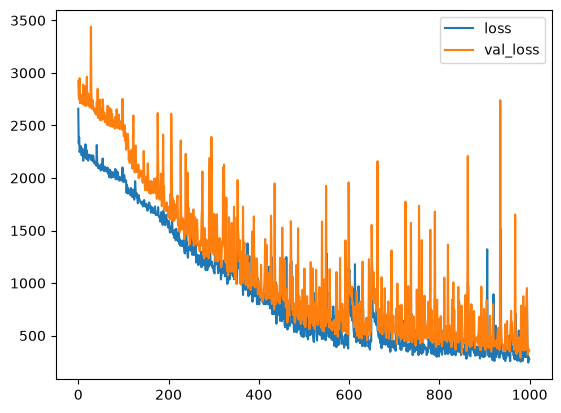

In [177]:
# let's use pandas for this (easy code)
# try to look if the model is actually training 
# => the error is going downwards
# if using validation data, you get two lines
# in this case, see if the lines follow a similar trend 
# (they don't always overlap with complex data, the trend is more important)
loss_df = pd.DataFrame(model.history.history)
loss_df.plot()



In [178]:
# compare the final model loss/evaluation values
print("Test data evaluation:")
print(model.evaluate(X_test, y_test, verbose=0))
print("\nTrain data evaluation:")
print(model.evaluate(X_train, y_train, verbose=0))



Test data evaluation:
313.5111389160156

Train data evaluation:
214.10511779785156


In [179]:
# get test predictions
test_predictions = model.predict(X_test)

# reshape the data for easier comparison table
test_predictions = pd.Series(test_predictions.reshape(len(y_test),))
pred_df = pd.DataFrame(np.asarray(y_test), columns=['Test True Y'])
pred_df = pd.concat([pred_df, test_predictions], axis=1)
pred_df.columns = ['Test True Y', 'Model Predictions']

# print the comparison table - true values vs. model predicted values
# we can nicely see here how far off our model is in some cases
pred_df



28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 972us/step


,Test True Y,Model Predictions
0,65.8800,71.107765
1,37.9924,43.286545
2,47.9520,39.209175
3,12.4671,9.684089
4,10.1322,7.659209
...,...,...
879,31.1922,27.814003
880,25.3980,21.616432
881,65.8800,96.171165
882,36.5878,36.976219


<Axes: xlabel='Test True Y', ylabel='Model Predictions'>

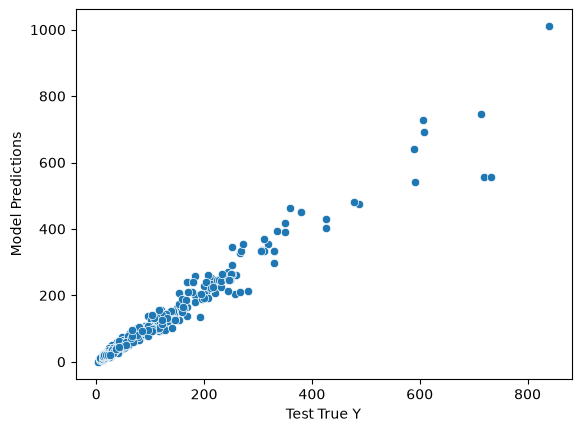

In [180]:
# these values follow a linear diagonal line = good predictions
# we basically compare the predicted values 
# to true test values and see the differences
sns.scatterplot(x='Test True Y', y='Model Predictions', data=pred_df)

In [181]:
# MAE - Mean average error
print("MAE")
print(round(metrics.mean_absolute_error(y_test, test_predictions), 2), "$")

# MSE - Mean square error
print("\nMSE")
print(round(metrics.mean_squared_error(y_test, test_predictions), 2), "$^2")

# RMSE - Root mean square error
print('\nRMSE:')
print(round(np.sqrt(metrics.mean_squared_error(y_test, test_predictions)), 2), "$")

# R-squared. 0 = the model descibes the dataset poorly
# 1 = model describes the dataset perfectly
print('\nR-squared:')
print(round(metrics.r2_score(y_test, test_predictions), 2))

# Explained Variance Score => 0 = the model descibes the dataset poorly
# 1 = model describes the dataset perfectly
# high variance score = model is a good fit for the data 
# low variance score = model is not a good fit for the data
# the higher the score, the model is more able to explain the variation in the data
# if score is low, we might need more and better data
print("\nExplained variance score:")
print(round(metrics.explained_variance_score(y_test, test_predictions), 2))

MAE
8.3 $

MSE
313.51 $^2

RMSE:
17.71 $

R-squared:
0.96

Explained variance score:
0.96


C:\Users\Niko Vuokila\AppData\Local\Temp\ipykernel_6148\2285612724.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot((y_test - test_predictions))


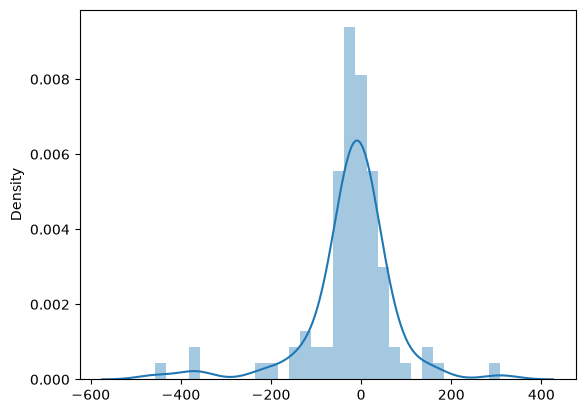

In [182]:
# if the prediction distribution are far from normal distribution
# then the model is not probably good enough
# distplot is deprecating in future pandas-version
# unfortunately, there's no exact alternative to do this plot at the moment
sns.distplot((y_test - test_predictions))
plt.show()
plt.close()

